In [1]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import exposure, filters
from skimage.feature import canny
import pandas as pd

In [2]:
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Set paths
base_dir = Path("D:/python_github/brain_tumor_dataset")
yes_dir = base_dir / "yes"
no_dir = base_dir / "no"

In [3]:
# load image and convert to grayscale numpy array
def load_img(path):
    img = Image.open(path).convert("L")  # convert to grayscale
    arr = np.array(img)
    return arr

In [4]:
# basic info for each image
records = []
for label, d in [("tumor", yes_dir), ("no_tumor", no_dir)]:
    for img_file in d.glob("*.*"):  # e.g. *.jpg, *.png
        try:
            arr = load_img(img_file)
            h, w = arr.shape
            mean = arr.mean()
            std = arr.std()
            mn = arr.min()
            mx = arr.max()
            # Edge density: fraction of edge pixels via Canny
            edges = canny(arr / 255.)
            edge_density = edges.mean()
            # Contrast: use skimage exposure
            contrast = arr.std() / (arr.mean()+1e-6)
            records.append({
                "filename": str(img_file.name),
                "label": label,
                "height": h,
                "width": w,
                "aspect_ratio": w/h,
                "mean_intensity": mean,
                "std_intensity": std,
                "min_intensity": mn,
                "max_intensity": mx,
                "edge_density": edge_density,
                "contrast": contrast
            })
        except Exception as e:
            print("Error reading", img_file, e)

df = pd.DataFrame(records)
print("Loaded metadata: ", df.shape)
df.head()

Loaded metadata:  (253, 11)


,filename,label,height,width,aspect_ratio,mean_intensity,std_intensity,min_intensity,max_intensity,edge_density,contrast
0,Y1.jpg,tumor,218,180,0.825688,75.786137,69.475034,0,-1,0.138124,0.916725
1,Y10.jpg,tumor,360,319,0.886111,109.885737,64.420857,11,-1,0.106583,0.586253
2,Y100.JPG,tumor,348,287,0.824713,51.962824,44.374548,0,-1,0.089701,0.853967
3,Y101.jpg,tumor,336,300,0.892857,51.240317,57.127960,0,-1,0.078760,1.114903
4,Y102.jpg,tumor,630,587,0.931746,74.947962,53.142917,0,-1,0.085106,0.709064


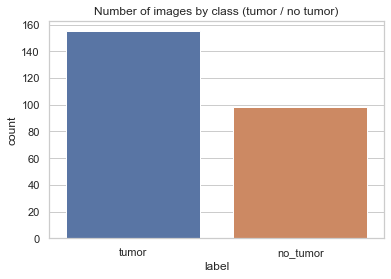

In [5]:
# Class balance
sns.countplot(x="label", data=df)
plt.title("Number of images by class (tumor / no tumor)")
plt.show()

Image size (height x width) summary:
            height        width  aspect_ratio
count   253.000000   253.000000    253.000000
mean    386.019763   354.237154      0.919033
std     213.128463   217.111684      0.168495
min     168.000000   150.000000      0.682454
25%     248.000000   225.000000      0.815789
50%     331.000000   278.000000      0.882500
75%     442.000000   400.000000      1.000000
max    1427.000000  1920.000000      1.785714


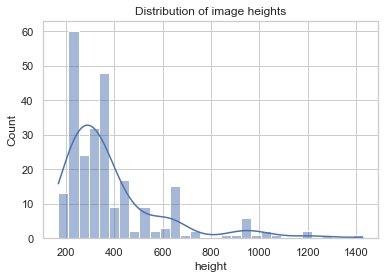

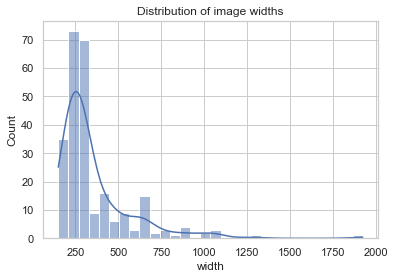

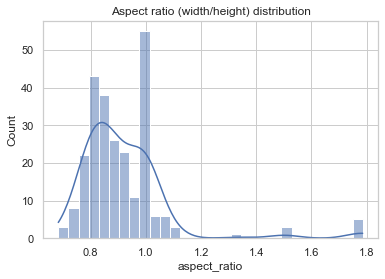

In [6]:
# Image sizes stats
print("Image size (height x width) summary:")
print(df[["height","width","aspect_ratio"]].describe())

sns.histplot(df["height"], bins=30, kde=True)
plt.title("Distribution of image heights")
plt.show()

sns.histplot(df["width"], bins=30, kde=True)
plt.title("Distribution of image widths")
plt.show()

sns.histplot(df["aspect_ratio"], bins=30, kde=True)
plt.title("Aspect ratio (width/height) distribution")
plt.show()

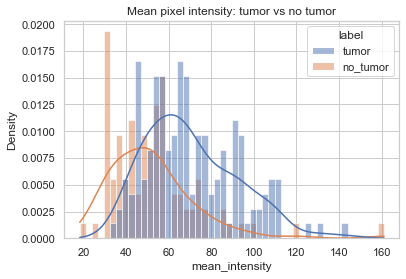

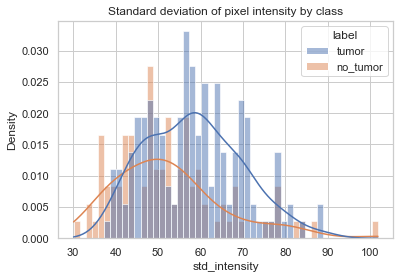

In [7]:
# Intensity distributions by class
sns.histplot(data=df, x="mean_intensity", hue="label", bins=50, kde=True, stat="density")
plt.title("Mean pixel intensity: tumor vs no tumor")
plt.show()

sns.histplot(data=df, x="std_intensity", hue="label", bins=50, kde=True, stat="density")
plt.title("Standard deviation of pixel intensity by class")
plt.show()

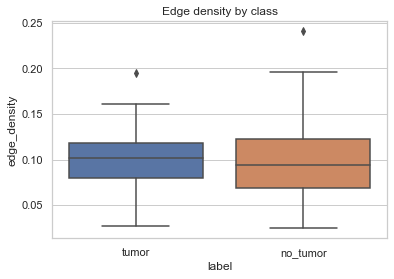

In [8]:
# Edge density by class
sns.boxplot(x="label", y="edge_density", data=df)
plt.title("Edge density by class")
plt.show()

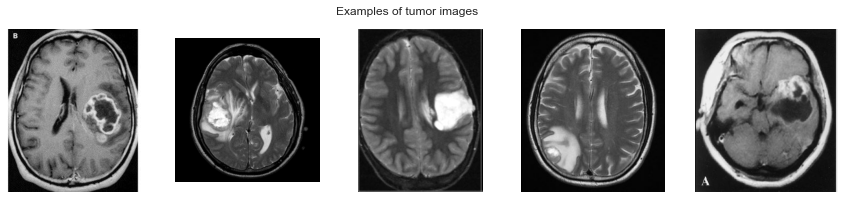

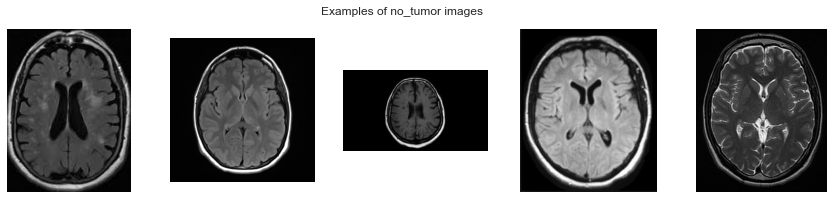

In [9]:
# Montage of random images
def plot_examples(label, n=5):
    fig, axes = plt.subplots(1, n, figsize=(n*3,3))
    selected = list((yes_dir if label=="tumor" else no_dir).glob("*.*"))
    np.random.seed(0)
    chosen = np.random.choice(selected, size=n, replace=False)
    for ax, p in zip(axes, chosen):
        img = load_img(p)
        ax.imshow(img, cmap='gray')
        ax.axis("off")
    fig.suptitle(f"Examples of {label} images")
    plt.show()

plot_examples("tumor", n=5)
plot_examples("no_tumor", n=5)

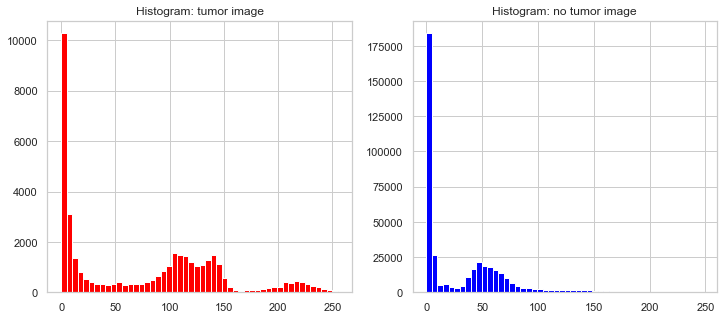

In [10]:
# Intensity histograms of individual images to compare shape
img_t = load_img(next(iter(yes_dir.glob("*.*"))))
img_n = load_img(next(iter(no_dir.glob("*.*"))))
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].hist(img_t.ravel(), bins=50, color='red')    # flatten() can also be used in place of ravel(). ravel is memory efficient
axes[0].set_title("Histogram: tumor image")
axes[1].hist(img_n.ravel(), bins=50, color='blue')
axes[1].set_title("Histogram: no tumor image")
plt.show()


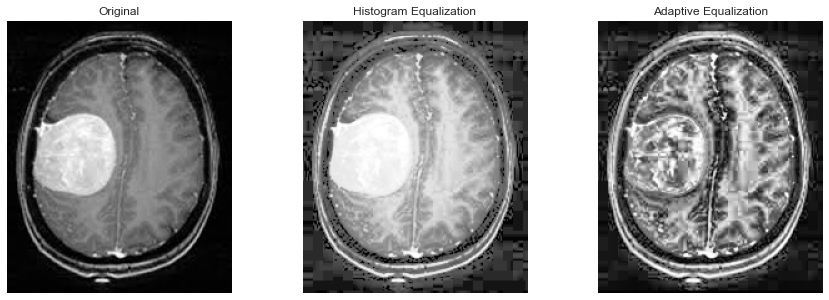

In [11]:
# Histogram equalization preview
fig, axes = plt.subplots(1,3, figsize=(15,5))
img = load_img(next(iter(yes_dir.glob("*.*"))))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")

# histogram equalization
eq = exposure.equalize_hist(img)
axes[1].imshow(eq, cmap='gray')
axes[1].set_title("Histogram Equalization")

# adaptive equalization
from skimage.exposure import equalize_adapthist
adapteq = equalize_adapthist(img, clip_limit=0.03)
axes[2].imshow(adapteq, cmap='gray')
axes[2].set_title("Adaptive Equalization")

for ax in axes:
    ax.axis("off")

plt.show()

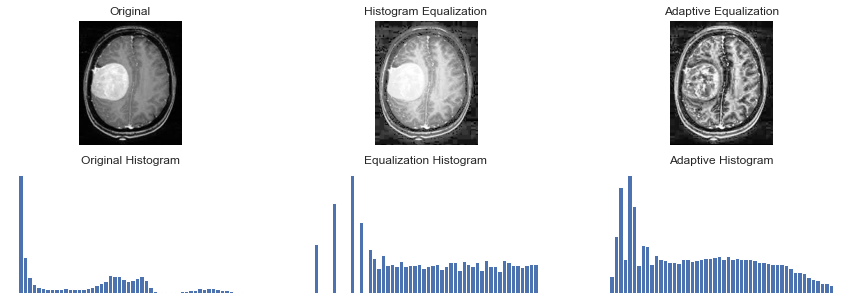

In [12]:
# Histogram equalization preview with histograms
fig, axes = plt.subplots(2,3, figsize=(15,5))
img = load_img(next(iter(yes_dir.glob("*.*"))))
axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title("Original")

# histogram equalization
eq = exposure.equalize_hist(img)
axes[0,1].imshow(eq, cmap='gray')
axes[0,1].set_title("Histogram Equalization")

# adaptive equalization
from skimage.exposure import equalize_adapthist
adapteq = equalize_adapthist(img, clip_limit=0.03)
axes[0,2].imshow(adapteq, cmap='gray')
axes[0,2].set_title("Adaptive Equalization")



axes[1,0].hist(img.ravel(), bins=50)
axes[1,0].set_title("Original Histogram")

axes[1,1].hist(eq.ravel(), bins=50)
axes[1,1].set_title("Equalization Histogram")

axes[1,2].hist(adapteq.ravel(), bins=50)
axes[1,2].set_title("Adaptive Histogram")

for ax in axes.ravel():
    ax.axis("off")
plt.show()


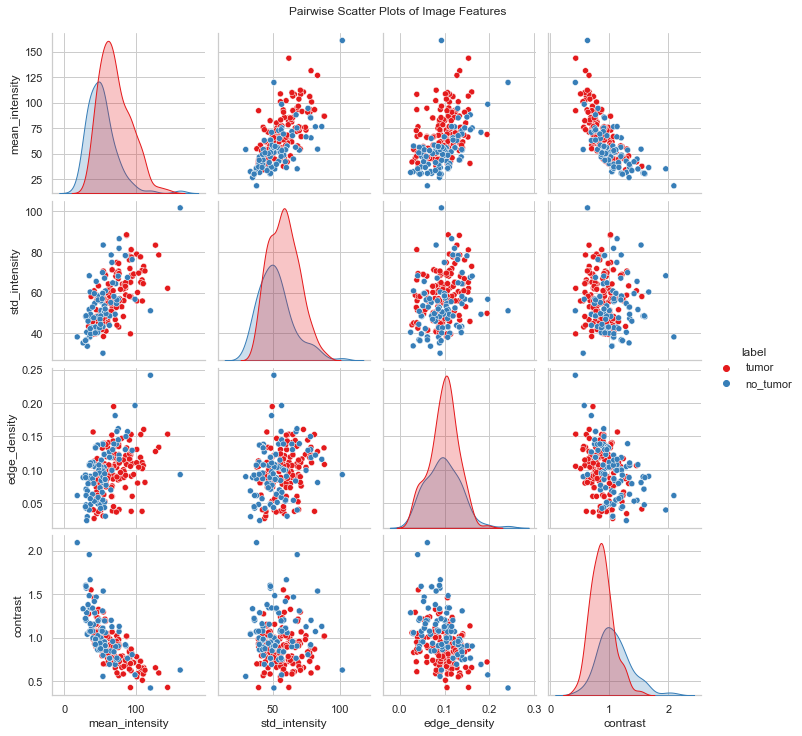

In [13]:
# Pairwise scatter plots colored by class
sns.pairplot(df,
             vars=['mean_intensity','std_intensity','edge_density','contrast'],
             hue='label',
             diag_kind='kde', palette='Set1')
plt.suptitle("Pairwise Scatter Plots of Image Features", y=1.02)
plt.show()

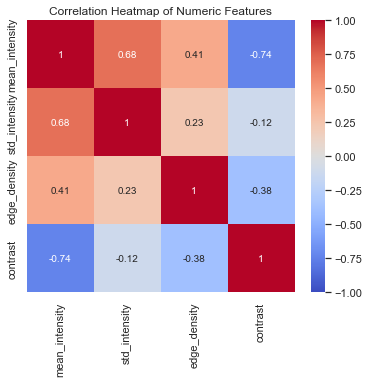

In [14]:
numeric_cols = ['mean_intensity','std_intensity','edge_density','contrast']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

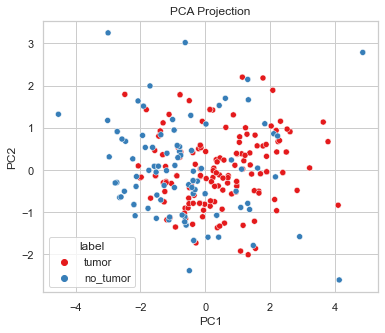

C:\Users\Shatakshi\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
C:\Users\Shatakshi\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


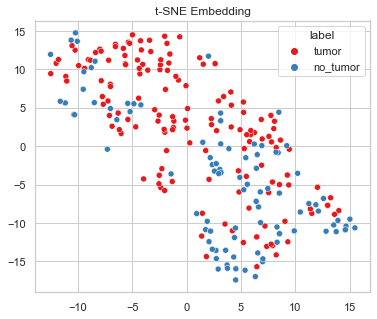

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X = df[numeric_cols]
y = df['label']

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# t-SNE (for non-linear structure)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='Set1')
plt.title("t-SNE Embedding")
plt.show()

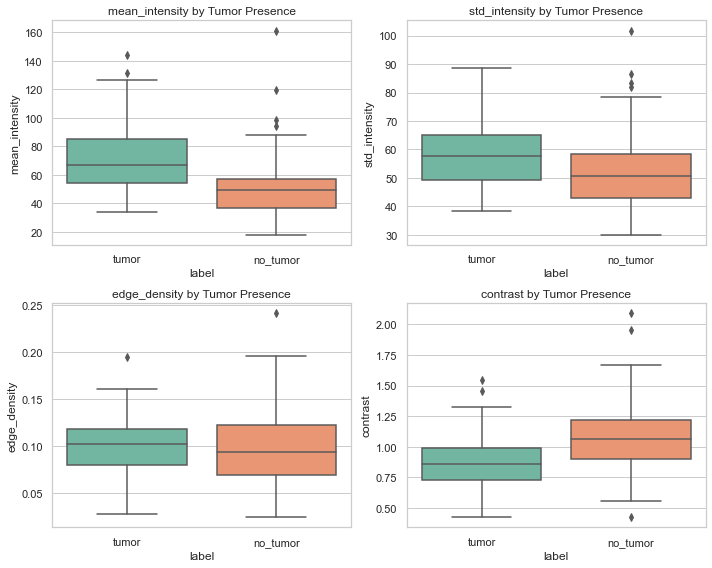

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))
features = ['mean_intensity','std_intensity','edge_density','contrast']

for ax, col in zip(axes.ravel(), features):
    sns.boxplot(x='label', y=col, data=df, palette='Set2', ax=ax)
    ax.set_title(f"{col} by Tumor Presence")
plt.tight_layout()
plt.show()